# Chapter 4.2 State-Space and Representation Assumptions

**TL;DR** — Isolates the Chapter 4.2 state-space experiments: toy branch leakage, representation changes, EB PC-versus-PHATE coupling diagnostics, and Euclidean versus manifold-aware paths. The reader finishes with the Chapter 4.2/4.3 small figures plus CSV/JSON diagnostics in `outputs/ch04`.

**Prerequisites** - Chapter 4.1 (coupling geometry).

**Outputs**
- `figures/ch04/fig4_5b_toy_branching_pairs.png`
- `figures/ch04/fig4_8_toy_representation_couplings.png`
- `figures/ch04/fig4_8b_eb_pc_vs_phate_coupling.png`
- `figures/ch04/fig4_2_toy_pca30_representative_pairs.png`
- `figures/ch04/fig4_2_toy_program4_representative_pairs.png`
- `figures/ch04/fig4_2_toy_representation_coupling_summary.png`
- `figures/ch04/fig4_2_state_space_model_readout_summary.png`
- `figures/ch04/fig4_2_eb_pc20_coupling_representative_pairs.png`
- `figures/ch04/fig4_2_eb_phate_diagnostic_coupling_representative_pairs.png`
- `figures/ch04/fig4_2_eb_pc_vs_phate_distance_summary.png`
- `figures/ch04/fig4_3_toy_single_pair_chord_vs_graph_path.png`
- `figures/ch04/fig4_3_eb_chord_vs_graph_matched_examples.png`
- `figures/ch04/fig4_3_eb_density_radius_delta.png`
- `figures/ch04/fig4_3_eb_knn_radius_delta.png`
- `figures/ch04/fig4_3_eb_off_manifold_positive_fraction.png`
- `outputs/ch04/eb_data_summary.json`
- `outputs/ch04/table4_2_toy_branch_diagnostics.csv`
- `outputs/ch04/table4_3_representation_coupling_diagnostics.csv`
- `outputs/ch04/table4_4_state_space_model_metrics.csv`
- `outputs/ch04/table4_5_eb_representation_coupling_diagnostics.csv`
- `outputs/ch04/exp8_pair_selection_diagnostics.csv`
- `outputs/ch04/exp8_off_manifold_stats.csv`
- `outputs/ch04/exp8_eb_pair_selection_diagnostics.csv`
- `outputs/ch04/exp8_eb_off_manifold_stats.csv`
- `outputs/ch04/exp8_eb_summary.json`
- `outputs/ch04/cache/exp5_toy_plans.npz`

**Runtime** - Chapter 4.2 uses `CH04_SMOKE_MODE` rather than a separate `QUICK_MODE`; smoke mode reduces CFM training steps, batch size, NFE, and path diagnostics for CI. On CPU, full mode is a multi-experiment run; smoke mode is the rough baseline for fast structural execution.

**Key parameters**
- `DEFAULT_SEED = 42` and `SEEDS = [42, 43, 44]` come from `make_ch04_run_config()`.
- EB bridge: source time `1` to target time `2`.
- State spaces compared: toy PCA-30, toy 4D program scores, EB standardized PC-20, and PHATE as a diagnostic display representation.
- Defaults: `TRAINING_STEPS = 1500`, `TOY_TRAINING_STEPS = TRAINING_STEPS`, `BATCH_SIZE = 256`, and `DEFAULT_NFE = 64`; smoke caps these.
- `SINKHORN_EPSILON = 0.05` controls the OT coupling diagnostics.
- Exp 8 graph diagnostics use selected toy and EB pairs plus density/KNN-radius readouts.

## 0. Setup

Imports, paths, device selection, random seeds, output directories, plotting style, cache helpers, and run-size controls.

Read this section as the reproducibility contract for the rest of the tutorial:
- defaults keep the requested chapter settings and write to `figures/ch04` plus `outputs/ch04`.
- environment variables are limited to smoke testing, bounded EB sampling, shorter training, or resuming cached work.
- Exp 8b remains cache-first; set `CH04_RECOMPUTE_EXP8B=1` only when intentionally rebuilding the full EB manifold diagnostic.


### Hypothesis
This setup assumes a shared Chapter 4 configuration can support toy and EB state-space diagnostics without changing artifact names.

### Setup
The cells establish imports, `config`, `SEEDS`, `SOURCE_TIME`, `TARGET_TIME`, `TRAINING_STEPS`, `BATCH_SIZE`, `DEFAULT_NFE`, output paths, and cache controls. They also import state-space plotting, artifact, and run-control helpers used by the following experiments.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch04")

from pathlib import Path
import json
import math
import time
import random
import hashlib
import warnings
from contextlib import redirect_stdout
import io
from dataclasses import dataclass
from typing import Callable, Iterable

warnings.filterwarnings("ignore", category=FutureWarning, message="You are using `torch.load`.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

try:
    import torch
    from torch import nn
except Exception as exc:
    raise ImportError("Chapter 4 experiments require PyTorch.") from exc

try:
    import anndata as ad
except Exception:
    ad = None

from scipy import sparse
from scipy.sparse.csgraph import shortest_path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

import sys

ROOT_HINT = Path.cwd().resolve()
if not (ROOT_HINT / "src").is_dir():
    ROOT_HINT = ROOT_HINT.parent
if str(ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(ROOT_HINT))

from src.tutorial_init import apply_tutorial_plot_style, bootstrap, make_ch04_run_config, make_save_and_show
from src.utils import set_seed

boot = bootstrap(chapter="ch04", seed=42, quick_mode=None)
PROJECT_ROOT = boot.project_root
FIG_DIR = boot.fig_dir
OUT_DIR = boot.out_dir
DEVICE = boot.device

from src.core.models import VelocityMLP as ProjectVelocityMLP, count_parameters
from src.core.losses import cfm_batch, cfm_loss_from_pairs
from src.core.train import train_cfm_steps
from src.core.sampling import euler_sample
from src.data.samplers import CouplingPairSampler as SrcCouplingPairSampler
from src.core.ot import independent_coupling, coupling_diagnostics
from src.evaluation.metrics import (
    fate_mass_error,
    coupling_l1_distance,
    distribution_readout_metrics,
)
from src.evaluation.representations import (
    pca_inverse_transform,
    readout_program_scores_from_matrix,
    standardize_train_space,
)


project_root=..
seed=42
quick_mode=None
fig_dir=figures/ch04
out_dir=outputs/ch04
device=cuda


In [2]:
config = make_ch04_run_config()
SEEDS = config.seeds
DEFAULT_SEED = config.default_seed
SOURCE_TIME = config.source_time
TARGET_TIME = config.target_time
TRAINING_STEPS = config.training_steps
BATCH_SIZE = config.batch_size
DEFAULT_NFE = config.default_nfe
NFE_GRID = config.nfe_grid
SINKHORN_EPSILON = config.sinkhorn_epsilon
EPSILON_GRID = config.epsilon_grid
SMOKE_MODE = config.smoke_mode
DEVICE = config.device
BOOTSTRAP_REPEATS = int(os.environ.get("CH04_BOOTSTRAP_REPEATS", "50"))
EB_MAX_CELLS_PER_TIME = os.environ.get("CH04_EB_MAX_CELLS_PER_TIME", "")
EB_MAX_CELLS_PER_TIME = None if EB_MAX_CELLS_PER_TIME == "" else int(EB_MAX_CELLS_PER_TIME)
TOY_TRAINING_STEPS = int(os.environ.get("CH04_TOY_TRAINING_STEPS", str(TRAINING_STEPS)))
if SMOKE_MODE:
    TOY_TRAINING_STEPS = min(TOY_TRAINING_STEPS, 20)
    BOOTSTRAP_REPEATS = min(BOOTSTRAP_REPEATS, 3)
    EB_MAX_CELLS_PER_TIME = 120 if EB_MAX_CELLS_PER_TIME is None else min(EB_MAX_CELLS_PER_TIME, 120)

DATA_DIR = PROJECT_ROOT / "data"
EB_PATH = DATA_DIR / "trajectorynet_eb" / "eb_velocity_v5.npz"
TOY_DIR = DATA_DIR / "toy_branching_snapshots"
TOY_CSV_PATH = TOY_DIR / "observed_2d_snapshots.csv"
TOY_H5AD_PATH = TOY_DIR / "branching_toy_pseudocounts.h5ad"

FIG_DIR = PROJECT_ROOT /  "figures" / "ch04"
OUT_DIR = PROJECT_ROOT /  "outputs" / "ch04"
if SMOKE_MODE:
    FIG_DIR = FIG_DIR / "smoke"
    OUT_DIR = OUT_DIR / "smoke"
CACHE_DIR = OUT_DIR / "cache"
for path in [FIG_DIR, OUT_DIR, CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

apply_tutorial_plot_style()
PALETTE = {
    "source": "#4C78A8",
    "target": "#F58518",
    "random": "#8E8E8E",
    "ot": "#008A7A",
    "reflow1": "#5369A6",
    "reflow2": "#B279A2",
    "rare": "#D95F02",
    "major": "#2C7FB8",
    "program": "#54A24B",
    "diagnostic": "#E45756",
}

print(
    f"Chapter 4.2 setup: device={DEVICE}, seed={DEFAULT_SEED}, "
    f"steps={TRAINING_STEPS}, toy_steps={TOY_TRAINING_STEPS}, "
    f"batch={BATCH_SIZE}, default_nfe={DEFAULT_NFE}, smoke={SMOKE_MODE}"
)


Chapter 4.2 setup: device=cuda, seed=42, steps=1500, toy_steps=1500, batch=256, default_nfe=64, smoke=False


In [3]:
import src.data.loading as ch04_data
import src.experiments.manifold as ch04_exp
import src.visualization.manifold as ch04t
from src.artifacts import display_saved_figure, json_ready, load_json, save_json
from src.artifacts import load_npz, load_pt, save_csv, save_npz, save_pt
from src.visualization.state_space import (
    axis_limits,
    choose_eb_path_example_ids,
    fmt_float,
    fmt_int,
    highest_mass_targets,
    load_eb_off_manifold_differences,
    plot_delta_distribution,
    plot_representative_endpoint_pairs,
    reconstruct_eb_graph_paths,
    representative_sources_from_plan,
    save_small_figure as _save_small_figure,
)

save_figure = lambda fig, filename, close=True: ch04t.save_ch04_figure(fig, FIG_DIR, filename, close=close)
save_small_figure = lambda fig, filename: _save_small_figure(fig, FIG_DIR, filename)

save_and_show = make_save_and_show(FIG_DIR, write_pdf=False, save_fn=save_figure)


In [4]:
from src.artifacts import artifact_exists, as_float32, ensure_finite, sample_rows, stable_hash, to_tensor


## 1. Shared Utilities

The cells below define chapter-level wrappers and helpers. They intentionally keep the key CFM/Sinkhorn/rollout/metric logic visible while reusing tested primitives from `src` where available.

The utilities are grouped for reading as well as execution:
- training and sampling wrappers provide the shared CFM interface used in toy and EB diagnostics.
- metric helpers keep endpoint, coupling, and density checks comparable within each section.
- artifact helpers centralize figure, CSV, JSON, and cache writes so the saved outputs stay consistent across sections.


### Hypothesis
The notebook assumes shared CFM, Sinkhorn, rollout, metric, and artifact helpers can be reused while keeping each state-space assumption explicit.

### Setup
The utility cells define `VelocityMLP`, `PlanPairSampler`, `train_or_load_model`, rollout wrappers, endpoint metrics, coupling diagnostics, and serialization helpers. Later experiments call these wrappers with their own data representation, plan, and readout variables.


In [5]:
from src.experiments.flow_runtime import make_time_batch, train_cfm
from src.experiments.flow_runtime import coarse_step_error as _coarse_step_error
from src.experiments.flow_runtime import rollout_euler as _rollout_euler, trajectory_rollout as _trajectory_rollout
from src.evaluation.metrics import coupling_topk_overlap, effective_support, evaluate_endpoint as _evaluate_endpoint, plan_entropy, topk_nn_overlap
from src.evaluation.metrics import mmd_rbf, off_manifold_knn, path_energy, path_length, straightness, straightness_action_S, tortuosity_straightness
from src.evaluation.metrics import sliced_w2 as _sliced_w2
from src.core.ot import compute_cost_matrix, sample_from_plan, sample_independent_pairs, sinkhorn_plan

VelocityMLP = ch04_exp.Ch04VelocityMLP
PlanPairSampler = ch04_exp.PlanPairSampler


def train_or_load_model(name, X0, X1, pi, steps=TRAINING_STEPS, seed=DEFAULT_SEED):
    buffer = io.StringIO()
    with redirect_stdout(buffer), warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=FutureWarning, message="You are using `torch.load`.*")
        return ch04_exp.train_or_load_model(
            name,
            X0,
            X1,
            pi,
            cache_dir=CACHE_DIR,
            steps=steps,
            batch_size=BATCH_SIZE,
            seed=seed,
            device=DEVICE,
            hidden=128,
            layers=4,
        )


rollout_euler = lambda model, x0, nfe=DEFAULT_NFE, device=DEVICE: _rollout_euler(model, x0, nfe=nfe, device=device)
trajectory_rollout = lambda model, x0, nfe=DEFAULT_NFE, return_path=True, device=DEVICE: _trajectory_rollout(
    model, x0, nfe=nfe, return_path=return_path, device=device
)
sliced_w2 = lambda X, Y, n_projections=128, seed=DEFAULT_SEED: _sliced_w2(
    X, Y, n_projections=n_projections, seed=seed
)
coarse_step_error = lambda model, x0, nfe_coarse=4, nfe_fine=64: _coarse_step_error(
    model, x0, nfe_coarse=nfe_coarse, nfe_fine=nfe_fine, device=DEVICE
)
evaluate_endpoint = lambda pred, target, seed=DEFAULT_SEED: _evaluate_endpoint(pred, target, seed=seed)

plot_phate_pairs = lambda X0_phate, X1_phate, idx0, idx1, title, max_lines=120, seed=DEFAULT_SEED, values=None: ch04t.plot_phate_pairs(
    X0_phate,
    X1_phate,
    idx0,
    idx1,
    fig_dir=FIG_DIR,
    title=title,
    max_lines=max_lines,
    seed=seed,
    values=values,
)
plot_pair_panels = lambda X0_phate, X1_phate, panels, filename, title, value_label="PC-20 chord length": ch04t.plot_pair_panels(
    X0_phate,
    X1_phate,
    panels,
    fig_dir=FIG_DIR,
    filename=filename,
    title=title,
    value_label=value_label,
)
add_local_arrows = ch04t.add_local_arrows
plot_projected_trajectories = lambda paths, X0_phate, X1_phate, pc_to_phate, filename, title, max_lines=45, local_arrows=True: ch04t.plot_projected_trajectories(
    paths,
    X0_phate,
    X1_phate,
    pc_to_phate,
    fig_dir=FIG_DIR,
    filename=filename,
    title=title,
    max_lines=max_lines,
    local_arrows=local_arrows,
    seed=DEFAULT_SEED,
)
plot_metric_lines = lambda table, x, y, hue, filename, title: ch04t.plot_metric_lines(
    table, fig_dir=FIG_DIR, x=x, y=y, hue=hue, filename=filename, title=title, nfe_grid=NFE_GRID
)
plot_heatmap = lambda matrix, title, filename, max_size=120, cmap="viridis": ch04t.plot_heatmap(
    matrix, fig_dir=FIG_DIR, title=title, filename=filename, max_size=max_size, cmap=cmap, seed=DEFAULT_SEED
)
plot_table_image = lambda frame, filename, title, max_rows=12: ch04t.plot_table_image(
    frame, fig_dir=FIG_DIR, filename=filename, title=title, max_rows=max_rows
)


## 2. Load EB Data

EB `pcs` is loaded from `eb_velocity_v5.npz`. This file stores 100 PCs, so this notebook explicitly takes the first 20 PCs and standardizes them using all EB snapshots. `phate` is kept as display-only coordinates. The main EB bridge is time label `1 -> 2`.

Tutorial checkpoints for downstream cells:
- standardized PC-20 endpoint arrays are used for EB coupling and Exp 8b graph diagnostics.
- PHATE endpoint aliases are used only for plotting selected endpoint pairs and trajectories.
- the summary JSON written here is part of the saved output set and should stay aligned with the displayed tables.

### Hypothesis
The EB state-space sections assume standardized PC-space arrays are the quantitative state representation, while PHATE remains display-only.

### Setup
`ch04_data.load_eb_data` creates the EB payload for the chapter bridge, including standardized PC endpoints and PHATE display endpoints. `fit_pc_to_phate_mapper` provides `pc_to_phate`, and `off_manifold_reference_pc` supplies the PC-space reference used later.


In [6]:
eb_load_log = io.StringIO()
with redirect_stdout(eb_load_log):
    EB = ch04_data.load_eb_data(
        EB_PATH,
        source_time=SOURCE_TIME,
        target_time=TARGET_TIME,
        out_dir=OUT_DIR,
        max_cells_per_time=EB_MAX_CELLS_PER_TIME,
        seed=DEFAULT_SEED,
    )
X0_eb, X1_eb = EB["X0_pc"], EB["X1_pc"]
X0p_eb, X1p_eb = EB["X0_phate"], EB["X1_phate"]
print("EB keys:", EB["keys"])
print(EB["counts"])
print("Source/target PC shapes:", EB["X0_pc"].shape, EB["X1_pc"].shape)
print("Summary saved to outputs/ch04/eb_data_summary.json")


EB keys: ['pcs', 'phate', 'delta_embedding', 'color', 'ixs', 'sample_labels', 'pcs_delta']
  time  n_cells
0    0     2381
1    1     4163
2    2     3278
3    3     3665
4    4     3332
Source/target PC shapes: (4163, 20) (3278, 20)
Summary saved to outputs/ch04/eb_data_summary.json


In [7]:
# Display-only mapping from PC-20 trajectory points back to PHATE for plotting.
# This is not used for training or endpoint distributional metrics.
pc_to_phate = ch04_data.fit_pc_to_phate_mapper(EB["pcs20_all"], EB["phate_all"], n_neighbors=15)
off_manifold_reference_pc = EB["pcs20_all"]
off_manifold_reference_note = "all available EB snapshots in standardized PC-20"
print(off_manifold_reference_note, off_manifold_reference_pc.shape)


all available EB snapshots in standardized PC-20 (16819, 20)


## Exp 5. Toy Branching: Coupling -> Branch Leakage

This controlled toy experiment uses toy fate labels only within toy data. It trains random, OT, oracle fate-preserving, and label-shuffled CFM models, then evaluates terminal fate leakage with a classifier trained on observed terminal toy states.

What to watch while running:
- the first code cell loads the `0.5 -> 1.0` toy bridge and constructs the four endpoint coupling plans.
- the training cell writes `table4_2_toy_branch_diagnostics.csv` and displays the diagnostic table.
- fate-label claims are toy-only; these labels are not used as EB biological labels.


### Hypothesis
This controlled toy experiment tests whether the coupling rule can induce branch leakage when toy fate labels are available for evaluation.

### Setup
The cells load the toy bridge into `X0_toy`, `X1_toy`, `y0_toy`, and `y1_toy`, then build `pi_toy_random`, `pi_toy_ot`, `pi_toy_oracle`, and `pi_toy_shuffled`. `train_or_load_model`, `trajectory_rollout`, and `terminal_classifier` produce the branch-leakage diagnostic table.


In [8]:
TOY_SOURCE_TIME = 0.5
TOY_TARGET_TIME = 1.0
TOY = ch04_data.load_toy_snapshots(TOY_CSV_PATH)
source_toy = TOY[np.isclose(TOY["time"], TOY_SOURCE_TIME)].reset_index(drop=True)
target_toy = TOY[np.isclose(TOY["time"], TOY_TARGET_TIME)].reset_index(drop=True)
if source_toy.empty or target_toy.empty:
    raise ValueError(f"Toy bridge {TOY_SOURCE_TIME}->{TOY_TARGET_TIME} is unavailable")
X0_toy_raw = source_toy[["state_1", "state_2"]].to_numpy(np.float32)
X1_toy_raw = target_toy[["state_1", "state_2"]].to_numpy(np.float32)
X0_toy, X1_toy, toy_state_meta = standardize_train_space(X0_toy_raw, X1_toy_raw)
y0_toy = source_toy["fate_label"].astype(str).to_numpy()
y1_toy = target_toy["fate_label"].astype(str).to_numpy()
y0_toy_eval = y0_toy.copy()
terminal_classifier = KNeighborsClassifier(n_neighbors=15, weights="distance")
terminal_classifier.fit(X1_toy, y1_toy)
print(TOY.groupby(["time", "fate_label"]).size().unstack(fill_value=0))
print("Exp 5 bridge:", TOY_SOURCE_TIME, "->", TOY_TARGET_TIME, "source labels", pd.Series(y0_toy).value_counts().to_dict(), "target labels", pd.Series(y1_toy).value_counts().to_dict())


fate_label  major  progenitor  rare
time                               
0.00            0         800     0
0.25            0         800     0
0.50          714           0    86
0.75          707           0    93
1.00          688           0   112
Exp 5 bridge: 0.5 -> 1.0 source labels {'major': 714, 'rare': 86} target labels {'major': 688, 'rare': 112}


In [9]:
C_toy_norm, C_toy_scale = compute_cost_matrix(X0_toy, X1_toy, normalize=True)
pi_toy_random = independent_coupling(len(X0_toy), len(X1_toy))
pi_toy_ot, info_toy_ot = sinkhorn_plan(C_toy_norm, epsilon=SINKHORN_EPSILON, return_info=True)
pi_toy_oracle = ch04_exp.fate_conditioned_plan(X0_toy, X1_toy, y0_toy, y1_toy)
y0_shuffled_for_plan = np.random.default_rng(123).permutation(y0_toy)
pi_toy_shuffled = ch04_exp.fate_conditioned_plan(X0_toy, X1_toy, y0_toy, y1_toy, source_labels_for_plan=y0_shuffled_for_plan)

toy_plans = {
    "random": pi_toy_random,
    "ot": pi_toy_ot,
    "oracle_fate_preserving": pi_toy_oracle,
    "label_shuffled_control": pi_toy_shuffled,
}
toy_plan_cache_path = save_npz(CACHE_DIR / "exp5_toy_plans.npz", **toy_plans)


In [10]:
toy_models = {}
toy_rows = []
for name, pi in toy_plans.items():
    model, hist = train_or_load_model(f"exp5_toy_{name}", X0_toy, X1_toy, pi, steps=TOY_TRAINING_STEPS, seed=60)
    toy_models[name] = model
    z, traj, times = trajectory_rollout(model, X0_toy, nfe=DEFAULT_NFE, return_path=True)
    pred_labels = terminal_classifier.predict(z)
    target_props = pd.Series(y1_toy).value_counts(normalize=True)
    pred_props = pd.Series(pred_labels).value_counts(normalize=True)
    branch_leakage = float(np.mean(pred_labels != y0_toy_eval))
    major_mask = y0_toy_eval == "major"
    rare_mask = y0_toy_eval == "rare"
    rare_err = abs(float(pred_props.get("rare", 0.0)) - float(target_props.get("rare", 0.0)))
    toy_rows.append({
        "method": name,
        "source_time": TOY_SOURCE_TIME,
        "target_time": TOY_TARGET_TIME,
        "branch_leakage": branch_leakage,
        "major_branch_leakage": float(np.mean(pred_labels[major_mask] != y0_toy_eval[major_mask])) if major_mask.any() else np.nan,
        "rare_branch_leakage": float(np.mean(pred_labels[rare_mask] != y0_toy_eval[rare_mask])) if rare_mask.any() else np.nan,
        "target_fate_mass_error": fate_mass_error(pred_labels, y1_toy),
        "rare_fate_mass_error": rare_err,
        "pred_rare_fraction": float(pred_props.get("rare", 0.0)),
        "target_rare_fraction": float(target_props.get("rare", 0.0)),
        "toy_label_scope": "toy-only controlled fate labels; not generalized to EB",
    })

toy_diag_table = pd.DataFrame(toy_rows)
save_csv(OUT_DIR / "table4_2_toy_branch_diagnostics.csv", toy_diag_table)
toy_diag_table


,method,source_time,target_time,branch_leakage,major_branch_leakage,rare_branch_leakage,target_fate_mass_error,rare_fate_mass_error,pred_rare_fraction,target_rare_fraction,toy_label_scope
0,random,0.5,1.0,0.09375,0.054622,0.418605,0.0575,0.02875,0.11125,0.14,toy-only controlled fate labels; not generaliz...
1,ot,0.5,1.0,0.09750,0.061625,0.395349,0.0400,0.02000,0.12000,0.14,toy-only controlled fate labels; not generaliz...
2,oracle_fate_preserving,0.5,1.0,0.08250,0.023810,0.569767,0.1450,0.07250,0.06750,0.14,toy-only controlled fate labels; not generaliz...
3,label_shuffled_control,0.5,1.0,0.09125,0.047619,0.453488,0.0775,0.03875,0.10125,0.14,toy-only controlled fate labels; not generaliz...


## Exp 6. Representation Space Changes Coupling

On the same toy cells, compare PCA-30 and 4D gene-program state spaces. Expected costs are normalized and reported only within their own representation; raw expected cost is not ranked across representations.

This section separates two questions:
- coupling diagnostics ask how endpoint pairings change when the cost is computed in PCA-30 versus gene-program space.
- model readout diagnostics train in each representation, then compare terminal readouts in the shared toy 4D gene-program score space.
- displayed artifacts are the small-figure set: `fig4_2_toy_pca30_representative_pairs.png`, `fig4_2_toy_program4_representative_pairs.png`, `fig4_2_toy_representation_coupling_summary.png`, and `fig4_2_state_space_model_readout_summary.png`.


### Hypothesis
This experiment tests whether changing the representation used for endpoint cost construction changes the coupling and model readout.

### Setup
`load_toy_expression_representations` creates PCA and program-space arrays, and `compute_cost_matrix` plus `sinkhorn_plan` build `pi_pca` and `pi_prog`. `train_or_load_model`, `trajectory_rollout`, `coupling_l1_distance`, and `coupling_topk_overlap` support coupling and shared-readout metrics.


In [11]:
TOY_REP = ch04_data.load_toy_expression_representations(TOY_H5AD_PATH, anndata_module=ad)
C_pca, scale_pca = compute_cost_matrix(TOY_REP["X0_pca"], TOY_REP["X1_pca"], normalize=True)
C_prog, scale_prog = compute_cost_matrix(TOY_REP["X0_prog"], TOY_REP["X1_prog"], normalize=True)
pi_pca, info_pca = sinkhorn_plan(C_pca, epsilon=SINKHORN_EPSILON, return_info=True)
pi_prog, info_prog = sinkhorn_plan(C_prog, epsilon=SINKHORN_EPSILON, return_info=True)
rep_l1 = coupling_l1_distance(pi_pca, pi_prog)
rep_nn_overlap = coupling_topk_overlap(pi_pca, pi_prog, k=15)
rep_rows = []
for name, pi, C, scale, info in [
    ("pca30", pi_pca, C_pca, scale_pca, info_pca),
    ("program4", pi_prog, C_prog, scale_prog, info_prog),
]:
    diag = coupling_diagnostics(pi, C)
    rep_rows.append({
        "representation": name,
        "epsilon": SINKHORN_EPSILON,
        "coupling_l1_vs_other_representation": rep_l1,
        "topk_nn_overlap_k15": rep_nn_overlap,
        "effective_support": diag["effective_support"],
        "entropy": diag["entropy"],
        "expected_cost_normalized_within_representation": diag["expected_cost"],
        "raw_expected_cost_comparison_allowed": False,
        "sinkhorn_converged": info["sinkhorn_converged"],
    })
rep_coupling_table = pd.DataFrame(rep_rows)
save_csv(OUT_DIR / "table4_3_representation_coupling_diagnostics.csv", rep_coupling_table)
rep_coupling_table


,representation,epsilon,coupling_l1_vs_other_representation,topk_nn_overlap_k15,effective_support,entropy,expected_cost_normalized_within_representation,raw_expected_cost_comparison_allowed,sinkhorn_converged
0,pca30,0.05,1.750089,0.042833,24629.001932,10.111680,0.608639,False,True
1,program4,0.05,1.750089,0.042833,144630.575716,11.881938,0.762924,False,True


In [12]:
rep_models = {}
rep_metric_rows = []
terminal_fate_classifier = KNeighborsClassifier(n_neighbors=min(15, len(TOY_REP["X1_prog_raw"])), weights="distance")
terminal_fate_classifier.fit(TOY_REP["X1_prog_raw"], TOY_REP["labels1"])

for name, X0_train, X1_train, pi in [
    ("pca30", TOY_REP["X0_pca"], TOY_REP["X1_pca"], pi_pca),
    ("program4", TOY_REP["X0_prog"], TOY_REP["X1_prog"], pi_prog),
]:
    model, hist = train_or_load_model(f"exp6_toy_{name}", X0_train, X1_train, pi, steps=TOY_TRAINING_STEPS, seed=70)
    rep_models[name] = model
    z, traj, times = trajectory_rollout(model, X0_train, nfe=DEFAULT_NFE, return_path=True)

    native_endpoint_mmd = mmd_rbf(z, X1_train)
    native_sliced_w2 = sliced_w2(z, X1_train, seed=76)

    if name == "program4":
        pred_readout = z * TOY_REP["prog_std"]["std"] + TOY_REP["prog_std"]["mean"]
        fate_note = "terminal fate predicted from generated Program-4 readout with target-readout KNN classifier"
    else:
        z_raw = z * TOY_REP["pca_std"]["std"] + TOY_REP["pca_std"]["mean"]
        expr_pred = pca_inverse_transform(z_raw, TOY_REP["pca_state"])
        pred_readout, _ = readout_program_scores_from_matrix(expr_pred, TOY_REP["programs"])
        fate_note = "PCA endpoint inverse-transformed to expression, then read out as 4D gene-program scores for target-readout KNN classifier"

    readout_metrics = distribution_readout_metrics(pred_readout, TOY_REP["X1_prog_raw"])
    pred_fate = terminal_fate_classifier.predict(pred_readout)
    rep_metric_rows.append({
        "model_training_representation": name,
        "native_endpoint_mmd": native_endpoint_mmd,
        "native_sliced_w2": native_sliced_w2,
        "program_readout_mmd": readout_metrics["program_readout_mmd"],
        "program_readout_sliced_w2": readout_metrics["program_readout_sliced_w2"],
        "program_readout_mae": readout_metrics["program_readout_mean_abs_error"],
        "program_readout_mean_abs_error": readout_metrics["program_readout_mean_abs_error"],
        "fate_mass_error": fate_mass_error(pred_fate, TOY_REP["labels1"]),
        "fate_mass_error_note": fate_note,
        "native_metric_cross_representation_comparable": False,
        "native_metric_scope": f"{name} native representation only; do not rank native metric values across representations",
        "readout_space": "shared toy 4D gene-program scores",
        "claim_boundary": "toy representation sensitivity only; toy fate labels are not generalized to EB",
    })
state_space_metrics = pd.DataFrame(rep_metric_rows)
save_csv(OUT_DIR / "table4_4_state_space_model_metrics.csv", state_space_metrics)
state_space_metrics


,model_training_representation,native_endpoint_mmd,native_sliced_w2,program_readout_mmd,program_readout_sliced_w2,program_readout_mae,program_readout_mean_abs_error,fate_mass_error,fate_mass_error_note,native_metric_cross_representation_comparable,native_metric_scope,readout_space,claim_boundary
0,pca30,0.005912,0.115796,0.009940,0.139212,0.032737,0.032737,0.025,PCA endpoint inverse-transformed to expression...,False,pca30 native representation only; do not rank ...,shared toy 4D gene-program scores,toy representation sensitivity only; toy fate ...
1,program4,0.001082,0.141447,0.001262,0.142720,0.040862,0.040862,0.050,terminal fate predicted from generated Program...,False,program4 native representation only; do not ra...,shared toy 4D gene-program scores,toy representation sensitivity only; toy fate ...


### Exp 6 Display: Representative Toy Endpoint Links

The next cell shows the same toy sources under PCA-30 and Program-4 coupling rules. Pair selection is defined in the stated metric space; the display remains in the original toy 2D coordinates.


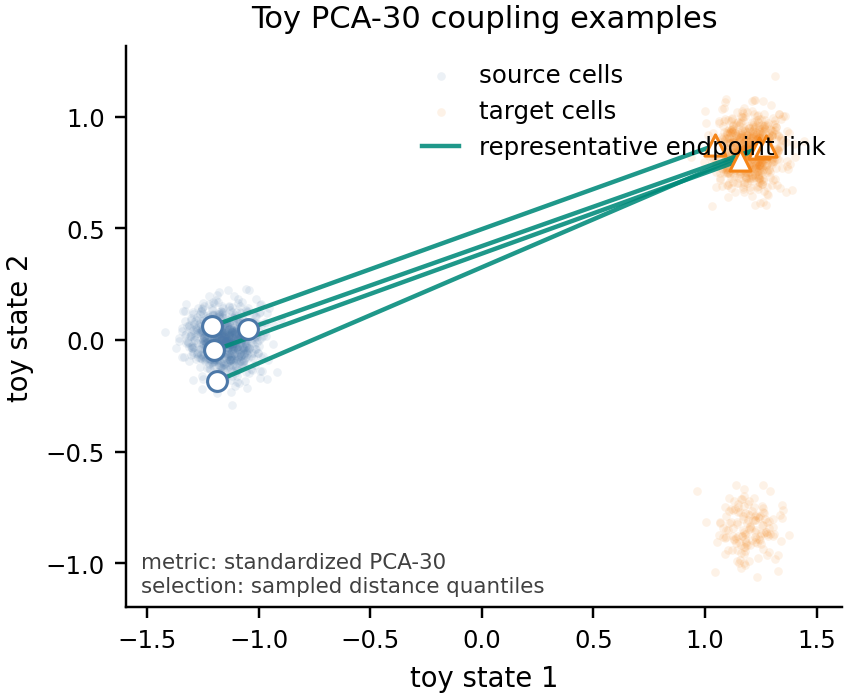

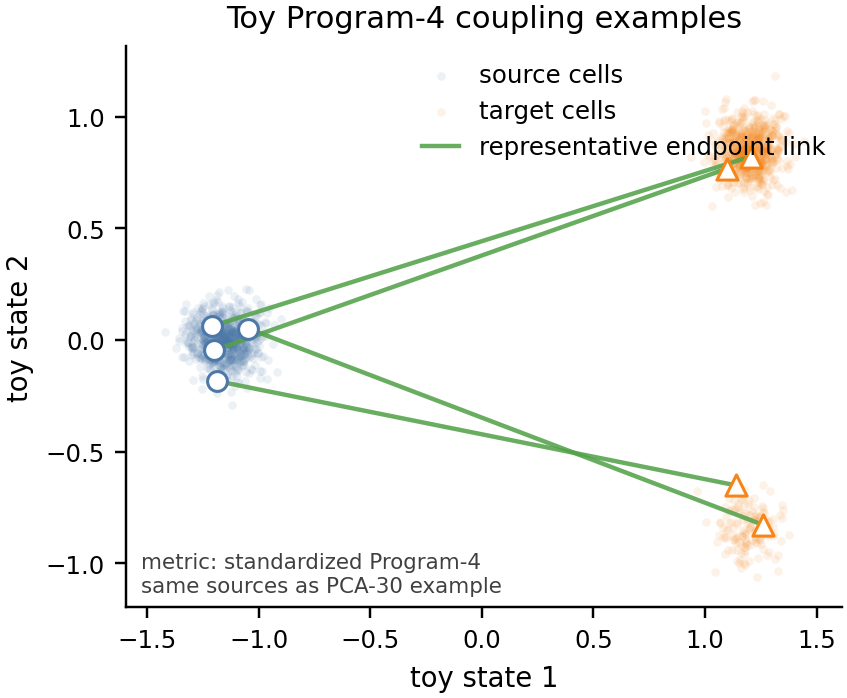

PCA-30 representative pairs
 quantile  source_idx  target_idx  sampled_metric_distance
     0.50         201         358                 6.065403
     0.75         652         105                 6.579484
     0.90         629         139                 7.073727
     0.95         349          44                 7.380125
Program-4 representative pairs
 quantile  source_idx  target_idx  sampled_metric_distance
     0.50         201         764                 6.065403
     0.75         652         423                 6.579484
     0.90         629         505                 7.073727
     0.95         349         172                 7.380125


In [13]:
toy_xlim, toy_ylim = axis_limits(TOY_REP["X0_viz"], TOY_REP["X1_viz"])
toy_pca_sources = representative_sources_from_plan(
    pi_pca,
    TOY_REP["X0_pca"],
    TOY_REP["X1_pca"],
    quantiles=(0.50, 0.75, 0.90, 0.95),
    seed=230,
)
toy_pca_pairs = toy_pca_sources.copy()
toy_pca_pairs["target_idx"] = highest_mass_targets(pi_pca, toy_pca_pairs["source_idx"].to_numpy())
plot_representative_endpoint_pairs(
    TOY_REP["X0_viz"],
    TOY_REP["X1_viz"],
    toy_pca_pairs,
    fig_dir=FIG_DIR,
    filename="fig4_2_toy_pca30_representative_pairs.png",
    title="Toy PCA-30 coupling examples",
    metric_note="metric: standardized PCA-30\nselection: sampled distance quantiles",
    line_color=PALETTE["ot"],
    xlim=toy_xlim,
    ylim=toy_ylim,
)

toy_prog_sources = representative_sources_from_plan(
    pi_pca,
    TOY_REP["X0_pca"],
    TOY_REP["X1_pca"],
    quantiles=(0.50, 0.75, 0.90, 0.95),
    seed=230,
)
toy_prog_pairs = toy_prog_sources.copy()
toy_prog_pairs["target_idx"] = highest_mass_targets(pi_prog, toy_prog_pairs["source_idx"].to_numpy())
plot_representative_endpoint_pairs(
    TOY_REP["X0_viz"],
    TOY_REP["X1_viz"],
    toy_prog_pairs,
    fig_dir=FIG_DIR,
    filename="fig4_2_toy_program4_representative_pairs.png",
    title="Toy Program-4 coupling examples",
    metric_note="metric: standardized Program-4\nsame sources as PCA-30 example",
    line_color=PALETTE["program"],
    xlim=toy_xlim,
    ylim=toy_ylim,
)
print("PCA-30 representative pairs")
print(toy_pca_pairs[["quantile", "source_idx", "target_idx", "sampled_metric_distance"]].to_string(index=False))
print("Program-4 representative pairs")
print(toy_prog_pairs[["quantile", "source_idx", "target_idx", "sampled_metric_distance"]].to_string(index=False))


### Exp 6 Display: Coupling and Model-Readout Summaries

These panels visualize the tables already written in Exp 6. Native endpoint metrics remain scoped to their own representation; shared readout metrics use toy Program-4 scores.


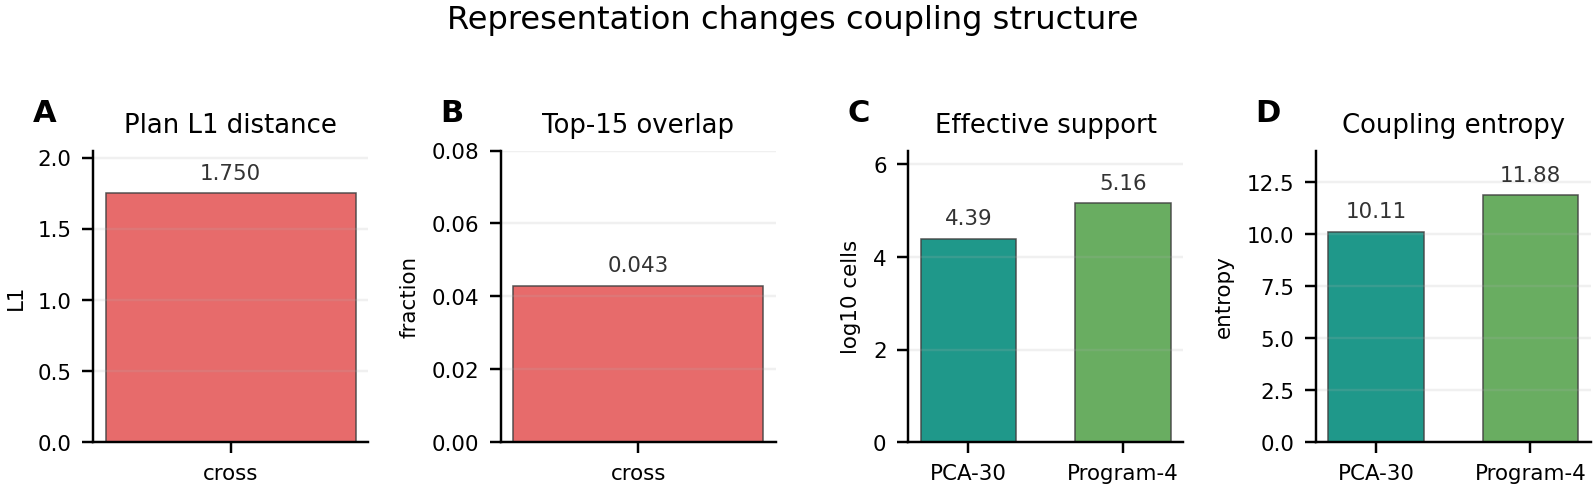

PosixPath('/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_single_cell_dynamic_biology/figures/ch04/fig4_2_toy_representation_coupling_summary.png')

In [14]:
rep_summary = pd.read_csv(OUT_DIR / "table4_3_representation_coupling_diagnostics.csv")
rep_summary["label"] = rep_summary["representation"].map({"pca30": "PCA-30", "program4": "Program-4"}).fillna(rep_summary["representation"])
l1_value = float(rep_summary["coupling_l1_vs_other_representation"].iloc[0])
overlap_value = float(rep_summary["topk_nn_overlap_k15"].iloc[0])
rep_colors = {"PCA-30": PALETTE["ot"], "Program-4": PALETTE["program"]}
plot_rows = rep_summary.reset_index(drop=True)
rep_labels = plot_rows["label"].tolist()
rep_color_values = [rep_colors[label] for label in rep_labels]
support_log = np.log10(plot_rows["effective_support"].to_numpy(dtype=float))
entropy_values = plot_rows["entropy"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 4, figsize=(7.4, 2.65))
coupling_bar_specs = [
    ("A", "Plan L1 distance", np.array([l1_value]), ["cross"], [PALETTE["diagnostic"]], 3, (0.0, 2.05), "L1"),
    ("B", "Top-15 overlap", np.array([overlap_value]), ["cross"], [PALETTE["diagnostic"]], 3, (0.0, max(0.08, overlap_value * 1.35)), "fraction"),
    ("C", "Effective support", support_log, rep_labels, rep_color_values, 2, (0.0, max(support_log) * 1.22), "log10 cells"),
    ("D", "Coupling entropy", entropy_values, rep_labels, rep_color_values, 2, (0.0, max(entropy_values) * 1.18), "entropy"),
]
for ax, (panel, title, values, xlabels, colors, ndigits, ylim, ylabel) in zip(axes, coupling_bar_specs):
    x = np.arange(len(values))
    bars = ax.bar(x, values, color=colors, width=0.62, alpha=0.88, edgecolor="0.25", linewidth=0.5)
    ax.set_title(title, fontsize=8.5, pad=6)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_xticks(x, xlabels, rotation=0)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.18)
    ax.tick_params(axis="both", labelsize=7)
    ax.text(-0.22, 1.08, panel, transform=ax.transAxes, ha="left", va="bottom", fontsize=10, weight="bold")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.035 * (ylim[1] - ylim[0]), f"{value:.{ndigits}f}", ha="center", va="bottom", fontsize=7, color="0.20")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.suptitle("Representation changes coupling structure", fontsize=10.5, y=0.99)
fig.subplots_adjust(left=0.07, right=0.99, top=0.74, bottom=0.24, wspace=0.48)
save_small_figure(fig, "fig4_2_toy_representation_coupling_summary.png")


### Exp 6 Display: Shared Model-Readout Metrics

This summary uses the saved state-space metric table. Native endpoint metrics stay scoped to their own representation; the shared readout panels use toy Program-4 scores.


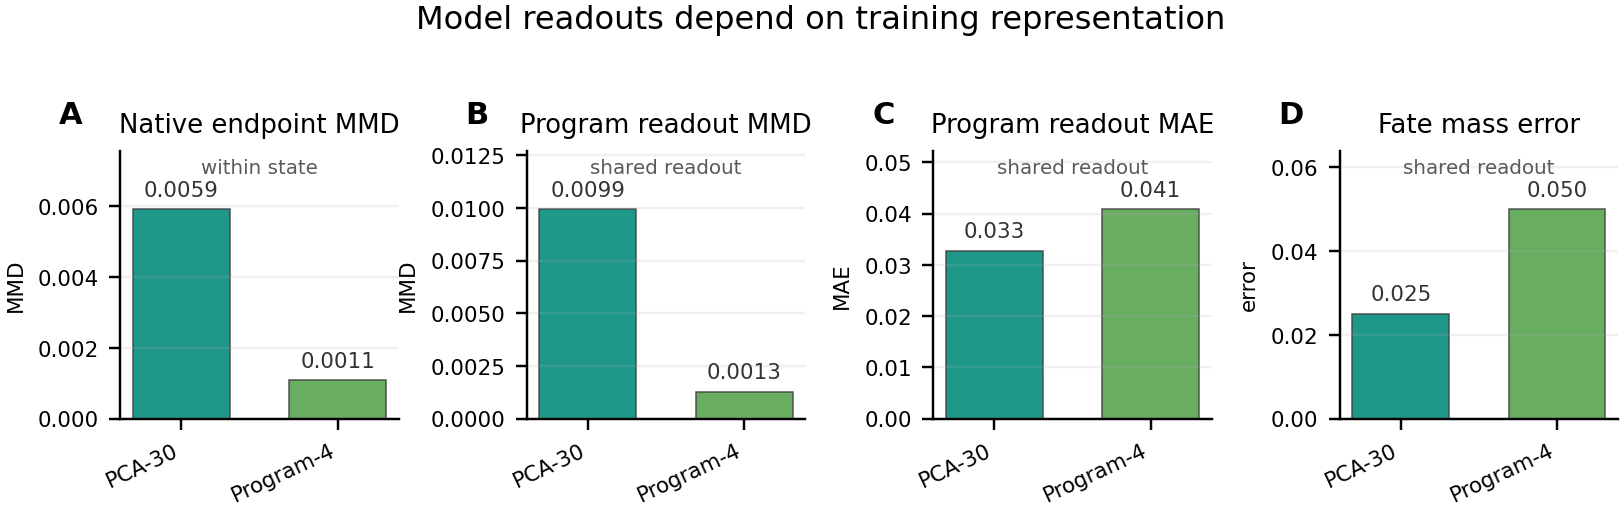

,model_training_representation,native_endpoint_mmd,program_readout_mmd,program_readout_mae,fate_mass_error
0,pca30,0.005912,0.009940,0.032737,0.025
1,program4,0.001082,0.001262,0.040862,0.050


In [15]:
state_metrics = pd.read_csv(OUT_DIR / "table4_4_state_space_model_metrics.csv")
state_metrics["label"] = state_metrics["model_training_representation"].map({"pca30": "PCA-30", "program4": "Program-4"}).fillna(state_metrics["model_training_representation"])
plot_rows = state_metrics.reset_index(drop=True)
labels = plot_rows["label"].tolist()
model_colors = {"PCA-30": PALETTE["ot"], "Program-4": PALETTE["program"]}
bar_colors = [model_colors[label] for label in labels]

fig, axes = plt.subplots(1, 4, figsize=(7.4, 2.65))
model_bar_specs = [
    ("A", "Native endpoint MMD", "native_endpoint_mmd", 4, "MMD", "within state"),
    ("B", "Program readout MMD", "program_readout_mmd", 4, "MMD", "shared readout"),
    ("C", "Program readout MAE", "program_readout_mae", 3, "MAE", "shared readout"),
    ("D", "Fate mass error", "fate_mass_error", 3, "error", "shared readout"),
]
for ax, (panel, title, col, ndigits, ylabel, note) in zip(axes, model_bar_specs):
    values = plot_rows[col].to_numpy(dtype=float)
    x = np.arange(len(values))
    ymax = max(float(values.max()) * 1.28, 1e-6)
    bars = ax.bar(x, values, color=bar_colors, width=0.62, alpha=0.88, edgecolor="0.25", linewidth=0.5)
    ax.set_title(title, fontsize=8.5, pad=6)
    ax.text(0.5, 0.97, note, transform=ax.transAxes, ha="center", va="top", fontsize=6.5, color="0.35")
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_xticks(x, labels, rotation=25, ha="right")
    ax.set_ylim(0.0, ymax)
    ax.grid(axis="y", alpha=0.18)
    ax.tick_params(axis="both", labelsize=7)
    ax.text(-0.22, 1.08, panel, transform=ax.transAxes, ha="left", va="bottom", fontsize=10, weight="bold")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.035 * ymax, f"{value:.{ndigits}f}", ha="center", va="bottom", fontsize=7, color="0.20")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.suptitle("Model readouts depend on training representation", fontsize=10.5, y=0.99)
fig.subplots_adjust(left=0.07, right=0.99, top=0.74, bottom=0.28, wspace=0.46)
save_small_figure(fig, "fig4_2_state_space_model_readout_summary.png")
display(state_metrics[["model_training_representation", "native_endpoint_mmd", "program_readout_mmd", "program_readout_mae", "fate_mass_error"]])


## Exp 7. EB Representation Sensitivity: PC vs PHATE Coupling

This is a contrastive diagnostic only. EB models are not trained in PHATE, and EB endpoint distributional metrics are not computed in PHATE.

The code compares PC-20 and PHATE-derived coupling structure, then displays the small-figure set `fig4_2_eb_pc20_coupling_representative_pairs.png`, `fig4_2_eb_phate_diagnostic_coupling_representative_pairs.png`, and `fig4_2_eb_pc_vs_phate_distance_summary.png`. Keep the distinction clear: PC-20 is the EB state space, PHATE is a visualization diagnostic.


### Hypothesis
This contrastive diagnostic tests whether a PHATE-derived coupling would differ from the PC-space EB coupling used for quantitative analysis.

### Setup
The cells compute `C_eb_pc`, `C_eb_phate`, `pi_eb_pc`, and `pi_eb_phate` with `compute_cost_matrix` and `sinkhorn_plan`. `coupling_l1_distance`, `coupling_topk_overlap`, `sample_from_plan`, and representative-pair plots summarize the contrast without training EB models in PHATE.


In [16]:
C_eb_pc, scale_eb_pc = compute_cost_matrix(X0_eb, X1_eb, normalize=True)
C_eb_phate, scale_eb_phate = compute_cost_matrix(X0p_eb, X1p_eb, normalize=True)
pi_eb_pc, info_eb_pc = sinkhorn_plan(C_eb_pc, epsilon=SINKHORN_EPSILON, return_info=True)
pi_eb_phate, info_eb_phate = sinkhorn_plan(C_eb_phate, epsilon=SINKHORN_EPSILON, return_info=True)
l1_eb = coupling_l1_distance(pi_eb_pc, pi_eb_phate)
overlap_eb = coupling_topk_overlap(pi_eb_pc, pi_eb_phate, k=15)
rows = []
for name, pi, C, info in [
    ("pc20_coupling", pi_eb_pc, C_eb_pc, info_eb_pc),
    ("phate2_contrastive_diagnostic", pi_eb_phate, C_eb_phate, info_eb_phate),
]:
    idx0, idx1 = sample_from_plan(pi, 4096, seed=82)
    diag = coupling_diagnostics(pi, C)
    rows.append({
        "representation": name,
        "epsilon": SINKHORN_EPSILON,
        "coupling_l1_vs_other": l1_eb,
        "topk_nn_overlap_k15": overlap_eb,
        "mean_sampled_pair_distance_pc20": float(np.linalg.norm(X1_eb[idx1] - X0_eb[idx0], axis=1).mean()),
        "mean_sampled_pair_distance_phate": float(np.linalg.norm(X1p_eb[idx1] - X0p_eb[idx0], axis=1).mean()),
        "normalized_expected_cost": diag["expected_cost"],
        "entropy": diag["entropy"],
        "effective_support": diag["effective_support"],
        "sinkhorn_converged": info["sinkhorn_converged"],
        "claim_boundary": "PHATE coupling is a contrastive display diagnostic only; no EB model trained in PHATE",
    })
eb_rep_table = pd.DataFrame(rows)
save_csv(OUT_DIR / "table4_5_eb_representation_coupling_diagnostics.csv", eb_rep_table)
eb_rep_table


,representation,epsilon,coupling_l1_vs_other,topk_nn_overlap_k15,mean_sampled_pair_distance_pc20,mean_sampled_pair_distance_phate,normalized_expected_cost,entropy,effective_support,sinkhorn_converged,claim_boundary
0,pc20_coupling,0.05,1.85032,0.004708,4.031853,68.670609,0.499907,12.804322,3.637864e+05,True,PHATE coupling is a contrastive display diagno...
1,phate2_contrastive_diagnostic,0.05,1.85032,0.004708,5.947911,49.761459,0.643597,15.024997,3.351763e+06,True,PHATE coupling is a contrastive display diagno...


### Exp 7 Display: EB Coupling Links and Metric Summary

The PC-20 links are selected in standardized PC-20. The PHATE diagnostic links use the same source examples but choose targets under the PHATE-induced coupling; PHATE remains display-only.


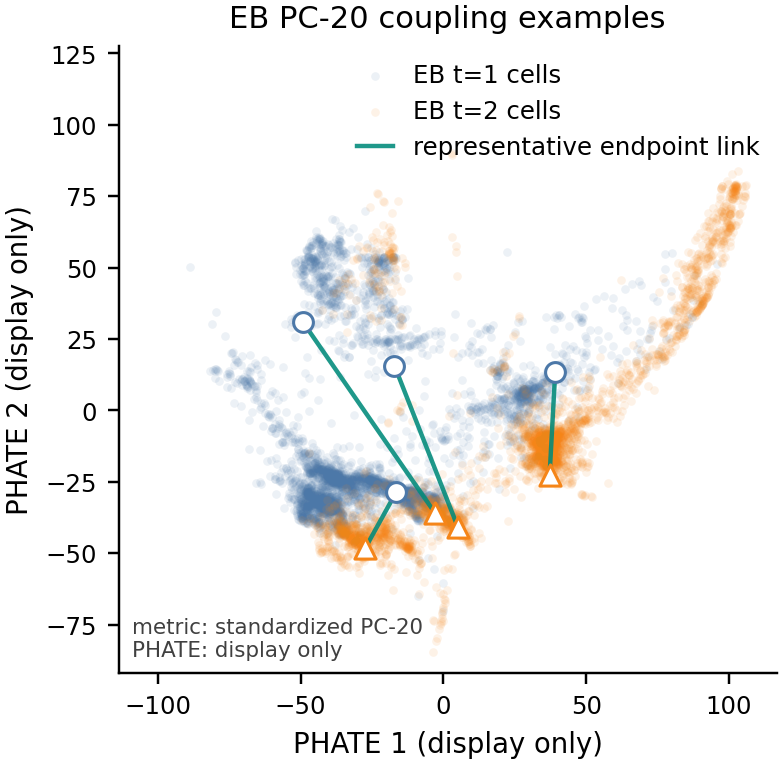

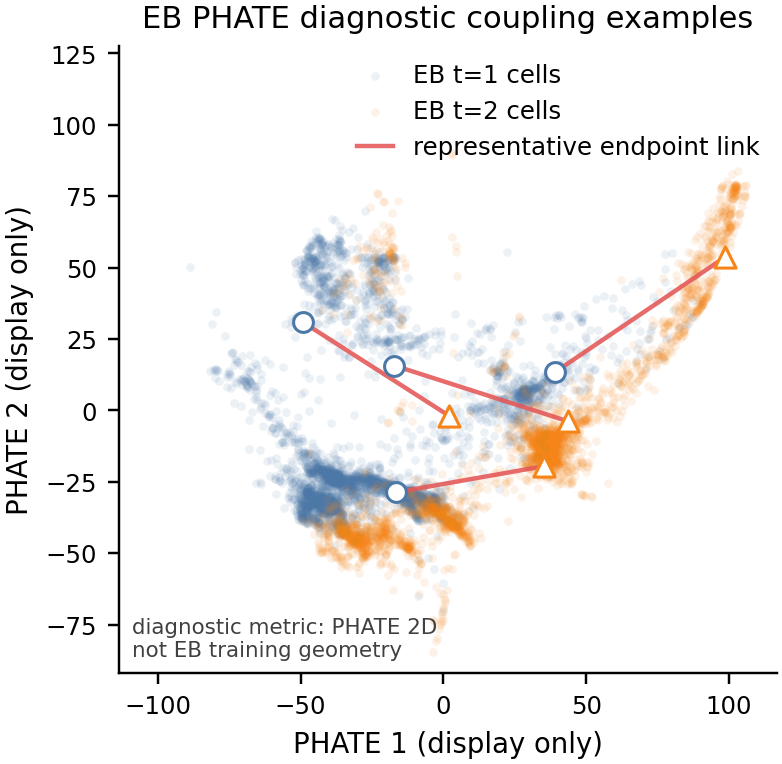

PC-20 representative pairs
 quantile  source_idx  target_idx  sampled_metric_distance
     0.50        3560        1034                 3.921707
     0.75        3193        1619                 4.567530
     0.90        1863        2851                 5.403730
     0.95        3409         237                 6.013863
PHATE diagnostic representative pairs
 quantile  source_idx  target_idx  sampled_metric_distance
     0.50        3560         813                 3.921707
     0.75        3193        1503                 4.567530
     0.90        1863         824                 5.403730
     0.95        3409         838                 6.013863


In [17]:
eb_xlim, eb_ylim = axis_limits(EB["phate_all"], pad=0.035)
eb_pc_sources = representative_sources_from_plan(
    pi_eb_pc,
    X0_eb,
    X1_eb,
    quantiles=(0.50, 0.75, 0.90, 0.95),
    seed=242,
)
eb_pc_pairs = eb_pc_sources.copy()
eb_pc_pairs["target_idx"] = highest_mass_targets(pi_eb_pc, eb_pc_pairs["source_idx"].to_numpy())
plot_representative_endpoint_pairs(
    X0p_eb,
    X1p_eb,
    eb_pc_pairs,
    fig_dir=FIG_DIR,
    filename="fig4_2_eb_pc20_coupling_representative_pairs.png",
    title="EB PC-20 coupling examples",
    metric_note="metric: standardized PC-20\nPHATE: display only",
    line_color=PALETTE["ot"],
    xlim=eb_xlim,
    ylim=eb_ylim,
    source_label="EB t=1 cells",
    target_label="EB t=2 cells",
)

eb_phate_sources = representative_sources_from_plan(
    pi_eb_pc,
    X0_eb,
    X1_eb,
    quantiles=(0.50, 0.75, 0.90, 0.95),
    seed=242,
)
eb_phate_pairs = eb_phate_sources.copy()
eb_phate_pairs["target_idx"] = highest_mass_targets(pi_eb_phate, eb_phate_pairs["source_idx"].to_numpy())
plot_representative_endpoint_pairs(
    X0p_eb,
    X1p_eb,
    eb_phate_pairs,
    fig_dir=FIG_DIR,
    filename="fig4_2_eb_phate_diagnostic_coupling_representative_pairs.png",
    title="EB PHATE diagnostic coupling examples",
    metric_note="diagnostic metric: PHATE 2D\nnot EB training geometry",
    line_color=PALETTE["diagnostic"],
    xlim=eb_xlim,
    ylim=eb_ylim,
    source_label="EB t=1 cells",
    target_label="EB t=2 cells",
)
print("PC-20 representative pairs")
print(eb_pc_pairs[["quantile", "source_idx", "target_idx", "sampled_metric_distance"]].to_string(index=False))
print("PHATE diagnostic representative pairs")
print(eb_phate_pairs[["quantile", "source_idx", "target_idx", "sampled_metric_distance"]].to_string(index=False))


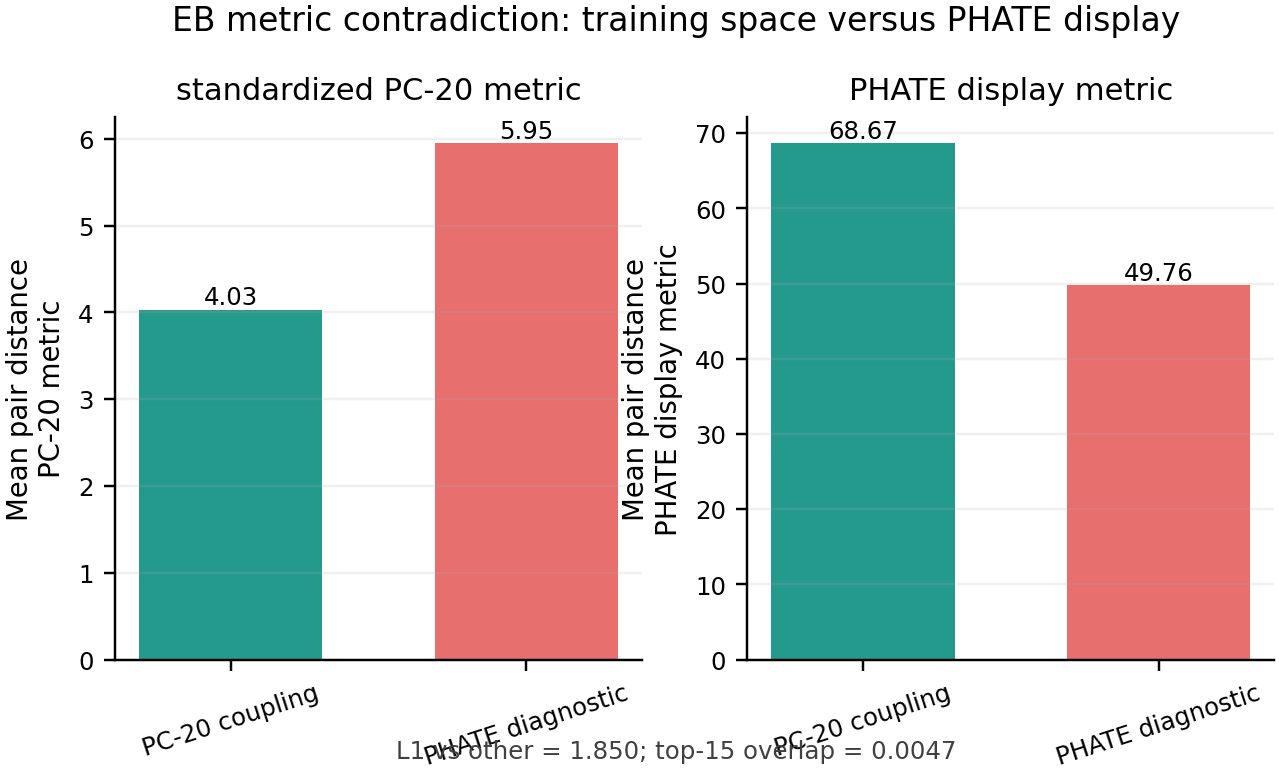

,representation,mean_sampled_pair_distance_pc20,mean_sampled_pair_distance_phate,coupling_l1_vs_other,topk_nn_overlap_k15
0,pc20_coupling,4.031853,68.670609,1.85032,0.004708
1,phate2_contrastive_diagnostic,5.947911,49.761459,1.85032,0.004708


In [18]:
eb_dist_summary = pd.read_csv(OUT_DIR / "table4_5_eb_representation_coupling_diagnostics.csv")
eb_dist_summary["coupling"] = eb_dist_summary["representation"].map({
    "pc20_coupling": "PC-20 coupling",
    "phate2_contrastive_diagnostic": "PHATE diagnostic",
}).fillna(eb_dist_summary["representation"])

fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.2))
metric_specs = [
    ("mean_sampled_pair_distance_pc20", "Mean pair distance\nPC-20 metric", "standardized PC-20 metric"),
    ("mean_sampled_pair_distance_phate", "Mean pair distance\nPHATE display metric", "PHATE display metric"),
]
for ax, (col, ylabel, title) in zip(axes, metric_specs):
    bars = ax.bar(
        eb_dist_summary["coupling"],
        eb_dist_summary[col],
        color=[PALETTE["ot"], PALETTE["diagnostic"]],
        alpha=0.86,
        width=0.62,
    )
    for bar, value in zip(bars, eb_dist_summary[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{float(value):.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=18)
    ax.grid(axis="y", alpha=0.18)
fig.text(
    0.5,
    -0.03,
    f"L1 vs other = {float(eb_dist_summary['coupling_l1_vs_other'].iloc[0]):.3f}; "
    f"top-15 overlap = {float(eb_dist_summary['topk_nn_overlap_k15'].iloc[0]):.4f}",
    ha="center",
    fontsize=8,
    color="0.25",
)
fig.suptitle("EB metric contradiction: training space versus PHATE display", y=1.04)
save_small_figure(fig, "fig4_2_eb_pc_vs_phate_distance_summary.png")
display(eb_dist_summary[["representation", "mean_sampled_pair_distance_pc20", "mean_sampled_pair_distance_phate", "coupling_l1_vs_other", "topk_nn_overlap_k15"]])


## Exp 8. Euclidean Chord vs Manifold-Aware Path

On toy data, compare straight endpoint interpolation with kNN-graph shortest paths on observed toy states. Intermediate diagnostics use density percentile and kNN radius at `t = {0.25, 0.5, 0.75}`.

The section builds a graph diagnostic, records pair-selection diagnostics, writes `exp8_pair_selection_diagnostics.csv` and `exp8_off_manifold_stats.csv`, then displays `fig4_3_toy_single_pair_chord_vs_graph_path.png`. EB-specific graph artifacts are handled only by Exp 8b below.


### Hypothesis
This diagnostic tests whether straight endpoint chords and kNN-graph paths encode different geometric assumptions on the observed toy manifold.

### Setup
The graph helpers build connected kNN graphs, density scorers, endpoint path caches, and selected pair diagnostics. `stats_for_selected_pairs`, `paired_path_differences`, and `plot_paths_2d` generate the chord-versus-graph tables and figures for the selected toy pairs.


### Step 8.1: graph and path helpers

These cells define the graph geometry used by the toy diagnostic before any pairs are selected.

In [19]:
from src.evaluation.graph_paths import build_connected_knn_graph, point_on_polyline, polyline_length, resample_polyline
from src.visualization.manifold_diagnostics import (
    build_endpoint_graph_grid,
    candidate_path_diagnostics,
    density_scorer,
    load_or_compute_ot_plan,
    paired_path_differences,
    plot_eb_path_statistics,
    plot_path_statistic_supplement,
    plot_paths_2d,
    select_diagnostic_pairs,
    stats_for_selected_pairs,
)

EXP8_T_VALUES = [0.25, 0.5, 0.75]
EXP8_GRAPH_K_GRID = [8, 12, 20, 30, 50, 80, 100, 150]
EXP8_CANDIDATE_PAIRS = 500 if SMOKE_MODE else 3000
EXP8_SELECTED_PAIRS = 8 if SMOKE_MODE else 16
EXP8_MIN_SELECTED_PAIRS = 6 if SMOKE_MODE else 10
EXP8_PATH_POINTS = 41



exp8_density_scorer = density_scorer
exp8_candidate_diagnostics = candidate_path_diagnostics
exp8_select_pairs = lambda candidate_diag: select_diagnostic_pairs(
    candidate_diag,
    max_pairs=EXP8_SELECTED_PAIRS,
    min_pairs=EXP8_MIN_SELECTED_PAIRS,
)
exp8_point_on_polyline = point_on_polyline
exp8_resample_polyline = lambda points, n_points=EXP8_PATH_POINTS: resample_polyline(points, n_points=n_points)


In [20]:
exp8_stats_for_selected = lambda selected_diag, source_points, target_points, path_cache, score_fn: stats_for_selected_pairs(
    selected_diag,
    source_points,
    target_points,
    path_cache,
    score_fn,
    t_values=EXP8_T_VALUES,
)
exp8_paired_differences = paired_path_differences


In [21]:
exp8_plot_supplement = lambda stats, filename, title: plot_path_statistic_supplement(
    stats,
    fig_dir=FIG_DIR,
    filename=filename,
    title=title,
    t_values=EXP8_T_VALUES,
    palette=PALETTE,
)

exp8_plot_paths_2d = lambda observed_points, source_points, target_points, selected_diag, path_cache, filename, title, max_pairs=16: plot_paths_2d(
    observed_points,
    source_points,
    target_points,
    selected_diag,
    path_cache,
    fig_dir=FIG_DIR,
    filename=filename,
    title=title,
    path_points=EXP8_PATH_POINTS,
    t_values=EXP8_T_VALUES,
    max_pairs=max_pairs,
    palette=PALETTE,
)


### Step 8.2: select toy pairs and write diagnostics

This step builds the kNN graph, samples candidate OT pairs, records why pairs are selected, and writes the pair diagnostics table.

In [22]:
# Toy Exp 8: build a real graph diagnostic, then select non-degenerate pairs.
all_toy_points = TOY[["state_1", "state_2"]].to_numpy(np.float32)
toy_graph, toy_graph_info, toy_graph_grid = build_connected_knn_graph(all_toy_points, k_grid=EXP8_GRAPH_K_GRID)
toy_score_fn, toy_ref_radius = exp8_density_scorer(all_toy_points, k=15)
toy_pair_diag, toy_path_cache = exp8_candidate_diagnostics(
    X0_toy_raw,
    X1_toy_raw,
    pi_toy_ot,
    all_toy_points,
    toy_graph,
    toy_score_fn,
    n_candidates=EXP8_CANDIDATE_PAIRS,
    seed=90,
)
for key, value in toy_graph_info.items():
    toy_pair_diag[key] = value
toy_pair_diag["graph_k_grid_tried"] = ",".join(str(r["k_graph"]) for r in toy_graph_grid)
toy_pair_diag["graph_components_by_k"] = ";".join(f"{r['k_graph']}:{r['n_components']}" for r in toy_graph_grid)
toy_pair_diag["graph_selection_note"] = (
    f"selected k={toy_graph_info['k_graph']} with {toy_graph_info['n_components']} connected component(s); "
    "smaller grid entries are retained in graph_components_by_k"
)
toy_pair_diag["candidate_set_size"] = int(EXP8_CANDIDATE_PAIRS)
toy_selected = exp8_select_pairs(toy_pair_diag)
toy_pair_diag["selected_for_figure"] = toy_pair_diag["pair_id"].isin(toy_selected["pair_id"]).astype(bool)
toy_pair_diag = toy_pair_diag.merge(
    toy_selected[["pair_id", "selected_rank", "selected_reason"]],
    on="pair_id",
    how="left",
)
toy_pair_diagnostics_path = save_csv(OUT_DIR / "exp8_pair_selection_diagnostics.csv", toy_pair_diag)


### Step 8.3: save and display toy path figures

The saved path and off-manifold-statistics figures are displayed immediately so the artifact can be inspected in the notebook.

In [23]:
exp8_stats = exp8_stats_for_selected(toy_selected, X0_toy_raw, X1_toy_raw, toy_path_cache, toy_score_fn)
save_csv(OUT_DIR / "exp8_off_manifold_stats.csv", exp8_stats)
exp8_stats.groupby(["path_type", "t"])[["density_radius_percentile", "knn_radius"]].mean()


density_radius_percentile  knn_radius
path_type               t                                          
knn_graph_shortest_path 0.25                  99.965625    0.217023
                        0.50                  91.015625    0.060445
                        0.75                  99.970313    0.214517
straight_chord          0.25                  99.965625    0.223422
                        0.50                  93.582813    0.071964
                        0.75                  99.976562    0.221318

In [24]:
toy_diffs = exp8_paired_differences(exp8_stats)
toy_diff_summary = toy_diffs.groupby("t")[["straight_minus_graph_density_percentile", "straight_minus_graph_knn_radius"]].mean()
toy_selected_nonfallback = int((~toy_selected["used_fallback"].astype(bool)).sum())
toy_selected_nodes_ge4 = int((toy_selected["graph_path_num_nodes"] >= 4).sum())
toy_candidate_fallback_count = int(toy_pair_diag["used_fallback"].astype(bool).sum())
toy_stats_not_identical = bool(
    (toy_diffs["straight_minus_graph_density_percentile"].abs().max() > 1e-9)
    or (toy_diffs["straight_minus_graph_knn_radius"].abs().max() > 1e-9)
)
toy_exp8_usable = bool(
    len(toy_selected) >= EXP8_MIN_SELECTED_PAIRS
    and toy_selected_nonfallback == len(toy_selected)
    and toy_selected_nodes_ge4 >= max(1, int(0.9 * len(toy_selected)))
    and toy_stats_not_identical
    and (
        toy_diff_summary["straight_minus_graph_knn_radius"].max() > 0
        or toy_diff_summary["straight_minus_graph_density_percentile"].max() > 0
    )
)
print("Exp 8 graph construction grid:")
display(pd.DataFrame(toy_graph_grid))
print("Exp 8 selected pairs:", len(toy_selected))
print("Exp 8 fallback candidate pairs:", toy_candidate_fallback_count)
print("Exp 8 selected nonfallback pairs:", toy_selected_nonfallback)
print("Exp 8 selected graph_path_num_nodes>=4:", toy_selected_nodes_ge4)
print("Exp 8 toy usable:", toy_exp8_usable)
print("Mean straight-minus-graph diagnostics by t:")
display(toy_diff_summary)


# EB real-data manifold diagnostic is implemented in the following Exp 8b cell.
# This toy cell does not generate EB artifacts, preventing fallback-based or metric-filtered EB examples.
eb_variant_generated = False
print("Dedicated EB Exp 8b cell handles EB PC-20 graph diagnostic; no EB fallback generated from toy cell.")

exp8_stats.groupby(["path_type", "t"])[["density_radius_percentile", "knn_radius"]].mean()


Exp 8 graph construction grid:


,k_graph,n_components,n_edges_undirected,graph_density,largest_component_fraction
0,8,4,19295,0.002412,0.60000
1,12,4,28654,0.003582,0.60000
2,20,4,47746,0.005968,0.60000
3,30,4,71982,0.008998,0.60000
4,50,4,121872,0.015234,0.60000
5,80,3,197063,0.024633,0.62325
6,100,1,247220,0.030902,1.00000


Exp 8 selected pairs: 16
Exp 8 fallback candidate pairs: 0
Exp 8 selected nonfallback pairs: 16
Exp 8 selected graph_path_num_nodes>=4: 16
Exp 8 toy usable: True
Mean straight-minus-graph diagnostics by t:


,straight_minus_graph_density_percentile,straight_minus_graph_knn_radius
t,,
0.25,0.000000,0.006400
0.50,2.567187,0.011519
0.75,0.006250,0.006801


Dedicated EB Exp 8b cell handles EB PC-20 graph diagnostic; no EB fallback generated from toy cell.


density_radius_percentile  knn_radius
path_type               t                                          
knn_graph_shortest_path 0.25                  99.965625    0.217023
                        0.50                  91.015625    0.060445
                        0.75                  99.970313    0.214517
straight_chord          0.25                  99.965625    0.223422
                        0.50                  93.582813    0.071964
                        0.75                  99.976562    0.221318

### Exp 8 Display: Toy Matched Chord and Graph Path

This single-pair view uses the selected toy path diagnostics to show how fixed endpoints can define different intermediate states under a straight chord versus a kNN-graph path.


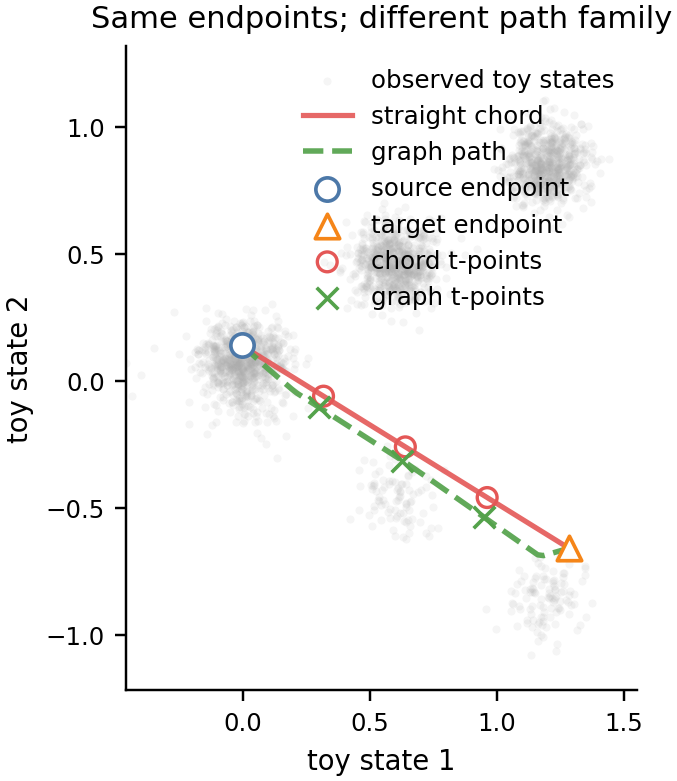

pair_id                                        1184
source_idx                                      177
target_idx                                      279
graph_path_num_nodes                              9
path_length_ratio                          1.028828
straight_minus_graph_density_percentile       2.025
straight_minus_graph_mid_knn_radius        0.050795


In [25]:
toy_path_diag = toy_pair_diag.copy() if "toy_pair_diag" in globals() else pd.read_csv(OUT_DIR / "exp8_pair_selection_diagnostics.csv")
toy_path_pool = toy_path_diag[
    (~toy_path_diag["used_fallback"].astype(bool))
    & (toy_path_diag["graph_path_num_nodes"] >= 8)
    & (
        (toy_path_diag["straight_minus_graph_mid_knn_radius"] > 0)
        | (toy_path_diag["straight_minus_graph_density_percentile"] > 0)
    )
].copy()
if toy_path_pool.empty:
    toy_path_pool = toy_path_diag[(~toy_path_diag["used_fallback"].astype(bool)) & (toy_path_diag["graph_path_num_nodes"] >= 4)].copy()
toy_path_row = toy_path_pool.sort_values(["path_length_ratio", "straight_minus_graph_density_percentile", "pair_id"], ascending=[False, False, True]).iloc[0]
toy_path_pair_id = int(toy_path_row["pair_id"])
start = X0_toy_raw[int(toy_path_row["source_idx"])]
end = X1_toy_raw[int(toy_path_row["target_idx"])]
graph_nodes = np.asarray(toy_path_cache[toy_path_pair_id], dtype=np.float32)
straight_path = np.linspace(start, end, 61)
graph_path = exp8_resample_polyline(graph_nodes, 61)
toy_xlim, toy_ylim = axis_limits(X0_toy_raw, X1_toy_raw)

fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.scatter(all_toy_points[:, 0], all_toy_points[:, 1], s=7, color="0.68", alpha=0.12, linewidths=0, label="observed toy states")
ax.plot(straight_path[:, 0], straight_path[:, 1], color=PALETTE["diagnostic"], linewidth=1.7, alpha=0.90, label="straight chord")
ax.plot(graph_path[:, 0], graph_path[:, 1], color=PALETTE["program"], linewidth=1.8, alpha=0.92, linestyle="--", label="graph path")
ax.scatter(start[0], start[1], s=58, marker="o", facecolor="white", edgecolor=PALETTE["source"], linewidth=1.2, zorder=5, label="source endpoint")
ax.scatter(end[0], end[1], s=64, marker="^", facecolor="white", edgecolor=PALETTE["target"], linewidth=1.2, zorder=5, label="target endpoint")
for n, tval in enumerate(EXP8_T_VALUES):
    spt = (1.0 - float(tval)) * start + float(tval) * end
    gpt = exp8_point_on_polyline(graph_nodes, float(tval))
    ax.scatter(spt[0], spt[1], s=42, marker="o", facecolors="none", edgecolors=PALETTE["diagnostic"], linewidths=1.1, zorder=5, label="chord t-points" if n == 0 else None)
    ax.scatter(gpt[0], gpt[1], s=50, marker="x", color=PALETTE["program"], linewidths=1.2, zorder=5, label="graph t-points" if n == 0 else None)
ax.set_title("Same endpoints; different path family")
ax.set_xlabel("toy state 1")
ax.set_ylabel("toy state 2")
ax.set_xlim(*toy_xlim)
ax.set_ylim(*toy_ylim)
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=False, loc="upper right", ncol=1)
save_small_figure(fig, "fig4_3_toy_single_pair_chord_vs_graph_path.png")
print(toy_path_row[["pair_id", "source_idx", "target_idx", "graph_path_num_nodes", "path_length_ratio", "straight_minus_graph_density_percentile", "straight_minus_graph_mid_knn_radius"]].to_string())


### Exp 8b. EB 20D PC Real-Data Manifold Diagnostic

This EB diagnostic uses standardized PC-20 for endpoint pairs, shortest-path construction, and support-distance metrics; PHATE is display-only. The notebook is cache-first so readers inspect the full EB result without stepping through several heavy guard cells. Set `CH04_RECOMPUTE_EXP8B=1` outside the reader notebook when the cache intentionally needs to be rebuilt.

Displayed artifacts in this reader flow are `fig4_3_eb_chord_vs_graph_matched_examples.png`, `fig4_3_eb_density_radius_delta.png`, `fig4_3_eb_knn_radius_delta.png`, and `fig4_3_eb_off_manifold_positive_fraction.png`.


In [26]:
recompute_exp8b = os.environ.get("CH04_RECOMPUTE_EXP8B", "0") == "1"
required_exp8b_artifacts = {
    "off_manifold_stats": OUT_DIR / "exp8_eb_off_manifold_stats.csv",
    "pair_selection_diagnostics": OUT_DIR / "exp8_eb_pair_selection_diagnostics.csv",
    "summary": OUT_DIR / "exp8_eb_summary.json",
}
missing_artifacts = [path for path in required_exp8b_artifacts.values() if not path.exists() or path.stat().st_size == 0]
if recompute_exp8b:
    raise RuntimeError(
        "The paper-facing notebook loads the full EB Exp 8b cache. "
        "Rebuild those artifacts with the Chapter 4 diagnostic workflow, then rerun this notebook."
    )
if missing_artifacts:
    missing_display = "\n".join(f"- {path.relative_to(PROJECT_ROOT)}" for path in missing_artifacts)
    raise FileNotFoundError(f"Missing EB Exp 8b artifacts:\n{missing_display}")

eb_stats = pd.read_csv(required_exp8b_artifacts["off_manifold_stats"])
eb_pair_diagnostics = pd.read_csv(required_exp8b_artifacts["pair_selection_diagnostics"])
eb_summary = json.loads(required_exp8b_artifacts["summary"].read_text())
print("Loaded cached full EB Exp 8b artifacts.")
print("State space:", eb_summary.get("state_space"))
print("Pair selection:", eb_summary.get("pair_selection_mode"))
print("Connected pair fraction:", f"{float(eb_summary.get('connected_pair_fraction', np.nan)):.3f}")
display(eb_stats.head())


Loaded cached full EB Exp 8b artifacts.
State space: 20D PC X_cost
Pair selection: ot_coupling_seeded_sample_no_metric_filter
Connected pair fraction: 1.000


,pair_id,source_idx,target_idx,source_global_node,target_global_node,t,graph_path_num_nodes,connected_pair,used_fallback,pair_selection_mode,...,no_metric_based_pair_selection,state_space,visualization_space,straight_minus_graph_density_percentile,straight_minus_graph_knn_radius,interpretation,path_type,density_radius_percentile,knn_radius,selected_for_main_figure
0,0,2743,2206,5124,8750,0.25,5,True,False,ot_coupling_seeded_sample_no_metric_filter,...,True,20D PC X_cost,PHATE 2D only,60.110589,0.949114,"density-aware diagnostic, not lineage inference",straight_chord,80.801475,3.272772,True
1,0,2743,2206,5124,8750,0.25,5,True,False,ot_coupling_seeded_sample_no_metric_filter,...,True,20D PC X_cost,PHATE 2D only,60.110589,0.949114,"density-aware diagnostic, not lineage inference",knn_graph_shortest_path,20.690885,2.323658,True
2,0,2743,2206,5124,8750,0.50,5,True,False,ot_coupling_seeded_sample_no_metric_filter,...,True,20D PC X_cost,PHATE 2D only,54.795172,0.897324,"density-aware diagnostic, not lineage inference",straight_chord,85.046673,3.389749,True
3,0,2743,2206,5124,8750,0.50,5,True,False,ot_coupling_seeded_sample_no_metric_filter,...,True,20D PC X_cost,PHATE 2D only,54.795172,0.897324,"density-aware diagnostic, not lineage inference",knn_graph_shortest_path,30.251501,2.492425,True
4,0,2743,2206,5124,8750,0.75,5,True,False,ot_coupling_seeded_sample_no_metric_filter,...,True,20D PC X_cost,PHATE 2D only,37.225757,0.752241,"density-aware diagnostic, not lineage inference",straight_chord,89.315655,3.539182,True


### Exp 8b Display: Matched EB Path Examples

The endpoint pairs and graph paths are computed in standardized PC-20. PHATE is used only to show the selected straight and graph paths in two dimensions.


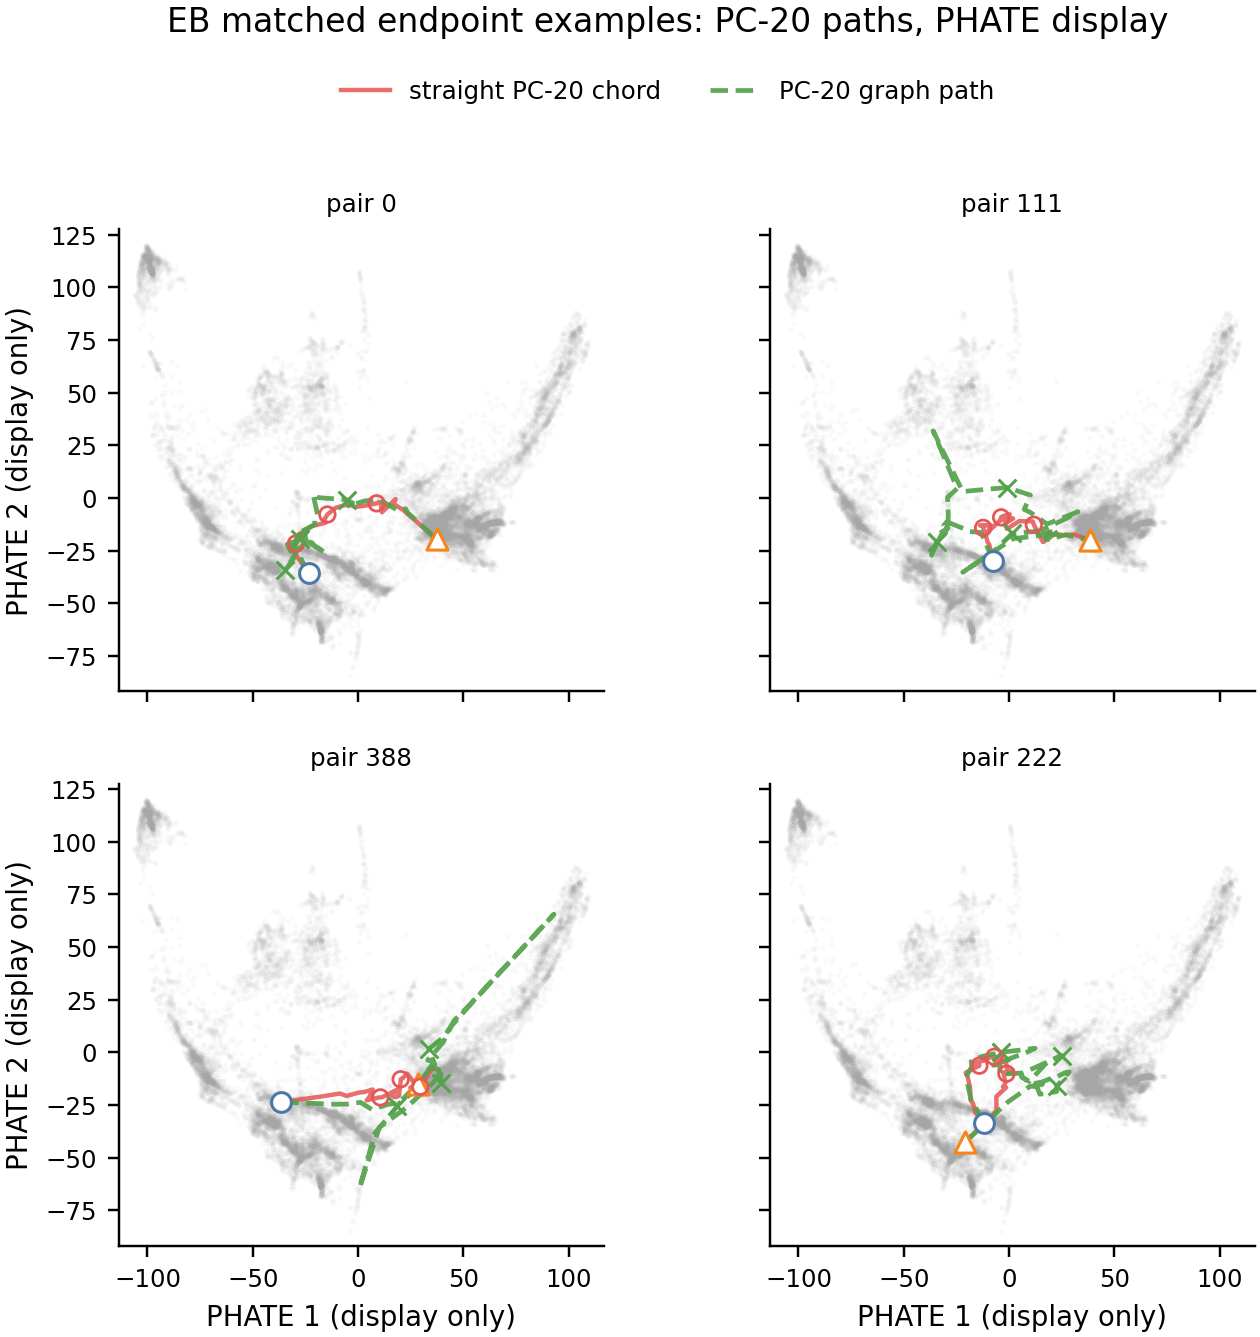

Selected EB path example pair ids: [0, 111, 388, 222]


In [27]:
import gc
for _large_name in [
    "C_eb_pc",
    "C_eb_phate",
    "pi_eb_pc",
    "pi_eb_phate",
    "C_pca",
    "C_prog",
    "pi_pca",
    "pi_prog",
]:
    if _large_name in globals():
        del globals()[_large_name]
gc.collect()

EXP8_EB_T_VALUES = [0.25, 0.5, 0.75]
EXP8_EB_PATH_POINTS = 41
eb_xlim, eb_ylim = axis_limits(EB["phate_all"], pad=0.035)
eb_path_pair_ids = choose_eb_path_example_ids(OUT_DIR, max_examples=4)
eb_path_rows = eb_pair_diagnostics[eb_pair_diagnostics["pair_id"].isin(eb_path_pair_ids)].copy()
eb_path_rows["plot_rank"] = eb_path_rows["pair_id"].map({pid: rank for rank, pid in enumerate(eb_path_pair_ids)})
eb_path_rows = eb_path_rows.sort_values("plot_rank")
eb_selected_paths = reconstruct_eb_graph_paths(eb_path_rows, EB["pcs20_all"], EB["X0_pc"], EB["X1_pc"])

fig, axes = plt.subplots(2, 2, figsize=(7.0, 6.0), sharex=True, sharey=True)
axes_flat = axes.ravel()
for ax, (_, row) in zip(axes_flat, eb_path_rows.iterrows()):
    pair_id = int(row["pair_id"])
    start_pc = X0_eb[int(row["source_idx"])]
    end_pc = X1_eb[int(row["target_idx"])]
    straight_pc = np.linspace(start_pc, end_pc, EXP8_EB_PATH_POINTS).astype(np.float32)
    graph_pc = resample_polyline(eb_selected_paths[pair_id], EXP8_EB_PATH_POINTS)
    straight_phate = pc_to_phate(straight_pc)
    graph_phate = pc_to_phate(graph_pc)
    ax.scatter(EB["phate_all"][:, 0], EB["phate_all"][:, 1], s=3, color="0.65", alpha=0.05, linewidths=0)
    ax.plot(straight_phate[:, 0], straight_phate[:, 1], color=PALETTE["diagnostic"], linewidth=1.45, alpha=0.86, label="straight PC-20 chord")
    ax.plot(graph_phate[:, 0], graph_phate[:, 1], color=PALETTE["program"], linewidth=1.55, linestyle="--", alpha=0.92, label="PC-20 graph path")
    source_ph = X0p_eb[int(row["source_idx"])]
    target_ph = X1p_eb[int(row["target_idx"])]
    ax.scatter(source_ph[0], source_ph[1], s=42, marker="o", facecolor="white", edgecolor=PALETTE["source"], linewidth=1.0, zorder=5)
    ax.scatter(target_ph[0], target_ph[1], s=48, marker="^", facecolor="white", edgecolor=PALETTE["target"], linewidth=1.0, zorder=5)
    for tval in EXP8_EB_T_VALUES:
        spt = pc_to_phate(((1.0 - float(tval)) * start_pc + float(tval) * end_pc)[None])[0]
        gpt = pc_to_phate(point_on_polyline(eb_selected_paths[pair_id], float(tval))[None])[0]
        ax.scatter(spt[0], spt[1], s=26, marker="o", facecolors="none", edgecolors=PALETTE["diagnostic"], linewidths=0.9, zorder=5)
        ax.scatter(gpt[0], gpt[1], s=34, marker="x", color=PALETTE["program"], linewidths=1.0, zorder=5)
    ax.set_title(f"pair {pair_id}", fontsize=8)
    ax.set_xlim(*eb_xlim)
    ax.set_ylim(*eb_ylim)
    ax.set_aspect("equal", adjustable="box")
for ax in axes[:, 0]:
    ax.set_ylabel("PHATE 2 (display only)")
for ax in axes[-1, :]:
    ax.set_xlabel("PHATE 1 (display only)")
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("EB matched endpoint examples: PC-20 paths, PHATE display", y=1.05)
save_small_figure(fig, "fig4_3_eb_chord_vs_graph_matched_examples.png")
print("Selected EB path example pair ids:", eb_path_pair_ids.tolist())


### Exp 8b Display: EB Support-Distance Deltas

These panels summarize straight-minus-graph support diagnostics from the cached PC-20 EB path table. Positive values mean the straight chord is farther from observed support than the graph path.


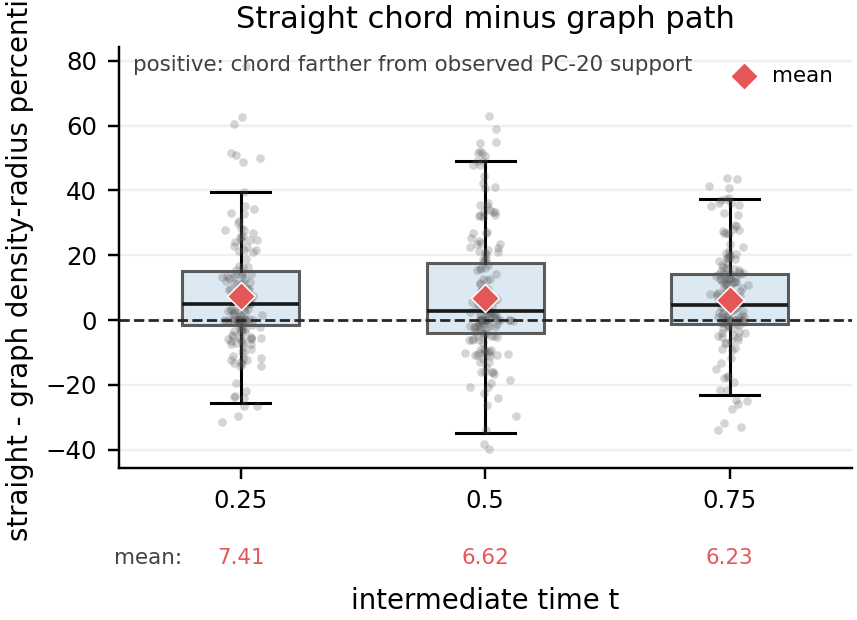

,t,mean_delta
0,0.25,7.411344
1,0.50,6.624270
2,0.75,6.231429


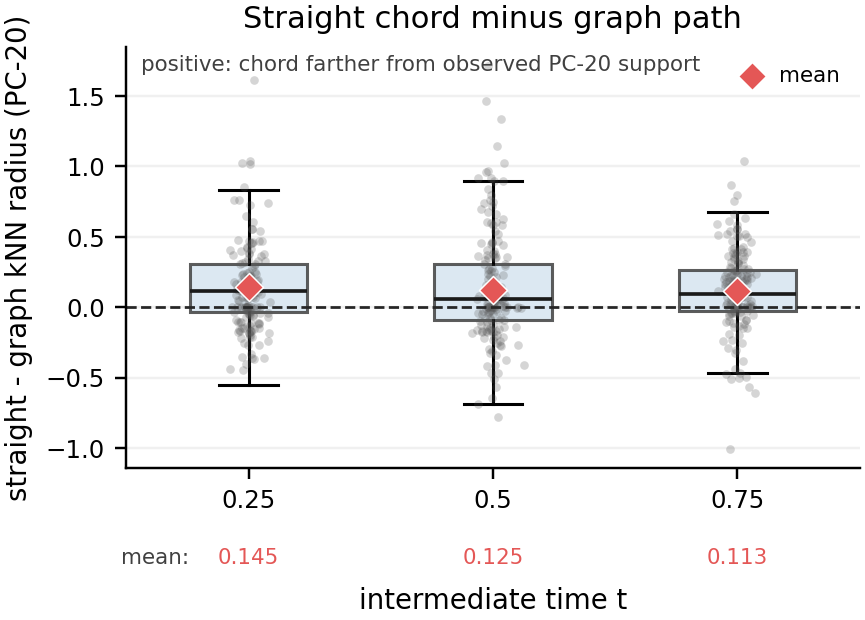

,t,mean_delta
0,0.25,0.145016
1,0.50,0.124682
2,0.75,0.113303


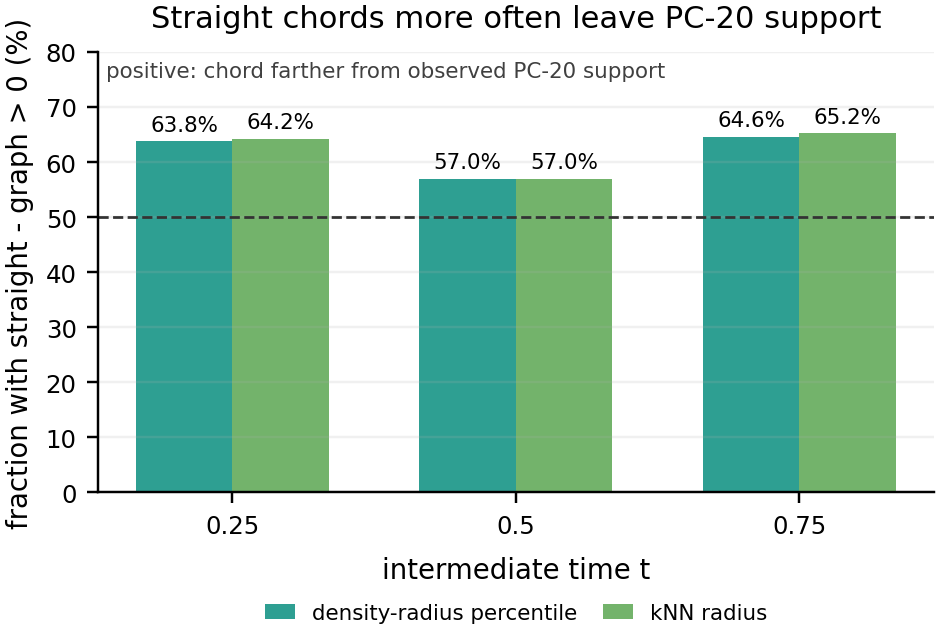

,t,density_radius_percentile,knn_radius
0,0.25,0.638,0.642
1,0.50,0.570,0.570
2,0.75,0.646,0.652


In [28]:
eb_diffs = load_eb_off_manifold_differences(OUT_DIR)
plot_delta_distribution(
    eb_diffs,
    "straight_minus_graph_density_percentile",
    "straight - graph density-radius percentile",
    fig_dir=FIG_DIR,
    filename="fig4_3_eb_density_radius_delta.png",
    mean_ndigits=2,
)
display(eb_diffs.groupby("t")["straight_minus_graph_density_percentile"].mean().rename("mean_delta").reset_index())

plot_delta_distribution(
    eb_diffs,
    "straight_minus_graph_knn_radius",
    "straight - graph kNN radius (PC-20)",
    fig_dir=FIG_DIR,
    filename="fig4_3_eb_knn_radius_delta.png",
    mean_ndigits=3,
)
display(eb_diffs.groupby("t")["straight_minus_graph_knn_radius"].mean().rename("mean_delta").reset_index())

positive_fraction = eb_diffs.groupby("t").agg(
    density_radius_percentile=("straight_minus_graph_density_percentile", lambda x: float((x > 0).mean())),
    knn_radius=("straight_minus_graph_knn_radius", lambda x: float((x > 0).mean())),
).reset_index()
fig, ax = plt.subplots(figsize=(4.9, 3.85))
x = np.arange(len(positive_fraction))
width = 0.34
bars1 = ax.bar(x - width / 2, 100 * positive_fraction["density_radius_percentile"], width=width, color=PALETTE["ot"], alpha=0.82, label="density-radius percentile")
bars2 = ax.bar(x + width / 2, 100 * positive_fraction["knn_radius"], width=width, color=PALETTE["program"], alpha=0.82, label="kNN radius")
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2, f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=7)
ax.axhline(50, color="0.2", linestyle="--", linewidth=0.9)
ax.set_xticks(x, [str(t) for t in positive_fraction["t"]])
ax.set_xlabel("intermediate time t", labelpad=6)
ax.set_ylabel("fraction with straight - graph > 0 (%)")
ymax = max(80, float(100 * positive_fraction[["density_radius_percentile", "knn_radius"]].to_numpy().max()) + 14)
ax.set_ylim(0, ymax)
ax.set_title("Straight chords more often leave PC-20 support", pad=8)
ax.text(0.01, 0.98, "positive: chord farther from observed PC-20 support", transform=ax.transAxes, ha="left", va="top", fontsize=7, color="0.25")
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.34), ncol=2, fontsize=7, handlelength=1.4, columnspacing=1.2)
ax.grid(axis="y", alpha=0.18)
fig.subplots_adjust(bottom=0.36, top=0.88)
save_small_figure(fig, "fig4_3_eb_off_manifold_positive_fraction.png")
display(positive_fraction)


## Take-aways

- *Finding 1* — This chapter compares state-space and representation assumptions without reinterpreting PHATE diagnostics as trained EB models or graph paths as true lineage.
- *Finding 2* — Toy branch, representation, and model-readout diagnostics keep native endpoint metrics scoped to their own representation and shared readouts in toy gene-program scores.
- *Finding 3* — EB manifold diagnostics compute endpoint pairs, graph paths, and support-distance metrics in standardized PC-20, with PHATE used only for two-dimensional display.

Next: → ch4_3
